## FriendPattern EEG Feature Extraction

In [1]:
# Import necessary libraries
import os
import pandas as pd
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Get files from directory
folder_path = "C:\\Users\\Sikhulile\\Downloads\\FriendPat Epilepsy Data"

def get_single_mat_file(index, folder_path):
    file_path = os.path.join(folder_path, os.listdir(folder_path)[index])
    return file_path 
index = 5  # Change this index to select different files from the folder
file_path = get_single_mat_file(index, folder_path)
filename = os.path.basename(file_path)

distinct_label = 'epilepsy'

if distinct_label in file_path:
        label = 1  # data label (1 for epilepsy, 0 for healthy)
else:
        label = 0  # data label (1 for epilepsy, 0 for healthy)
mat_data = loadmat(file_path)


cell_array= mat_data['data']
#print(cell_array)
print(cell_array.shape)
# Convert each cell into a DataFrame
dfs = []

for i in range(cell_array.shape[0]):
    for j in range(cell_array.shape[1]):
        # Extract the data from the cell
        data = cell_array[i, j]
        
        # Convert to DataFrame
        df = pd.DataFrame(data)
        
        # Add subject and trial information
        df['sample'] = i + 1  # Assuming subjects are indexed from 1
        df['channel'] = j + 1    # Assuming channels are indexed from 1
        
        dfs.append(df)
dfs = pd.concat(dfs, ignore_index=True)

# Create an index for each data point within a sample/channel
dfs['timepoint'] = dfs.groupby(['sample', 'channel']).cumcount()+1

# Rearrange: channels become columns
dfs = dfs.pivot(
    index=['sample', 'timepoint'],
    columns='channel',
    values=0
).reset_index()

# Clean column names
dfs.columns.name = None
dfs = dfs.rename(
    columns=lambda x: f'channel_{x}' if isinstance(x, int) else x
)

print(dfs.head())

(72, 36)
   sample  timepoint   channel_1   channel_2   channel_3   channel_4  \
0       1          1  161.861484  191.303411  220.737380  197.117599   
1       1          2  115.797982  136.884505  157.911555  141.029241   
2       1          3   69.562673   82.233412   94.896067   84.741389   
3       1          4   25.885387   30.586242   35.294511   31.507323   
4       1          5  -12.828572  -15.169174  -17.502889  -15.634520   

   channel_5   channel_6   channel_7  channel_8  ...  channel_27  channel_28  \
0  80.028061  284.238532  118.382854  -6.181338  ... -120.015707   -5.796115   
1  57.255795  203.351505   84.693201  -4.424769  ...  -85.860157   -4.145157   
2  34.407197  122.187847   50.894559  -2.655743  ...  -51.586879   -2.487945   
3  12.796868   45.450291   18.924508  -0.986379  ...  -19.175160   -0.924538   
4  -6.345406  -22.545711   -9.388363   0.496115  ...    9.520800    0.463768   

   channel_29  channel_30  channel_31  channel_32  channel_33  channel_34  \


(72, 630)


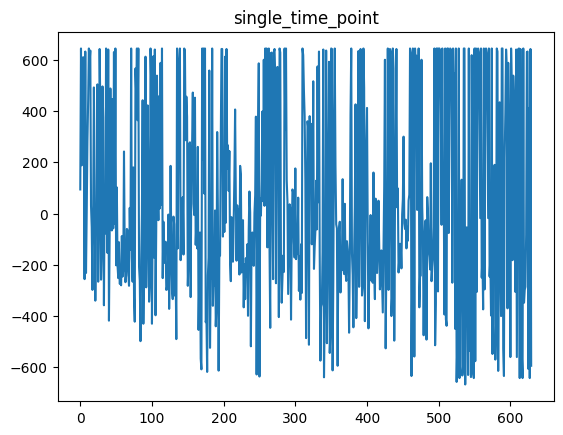

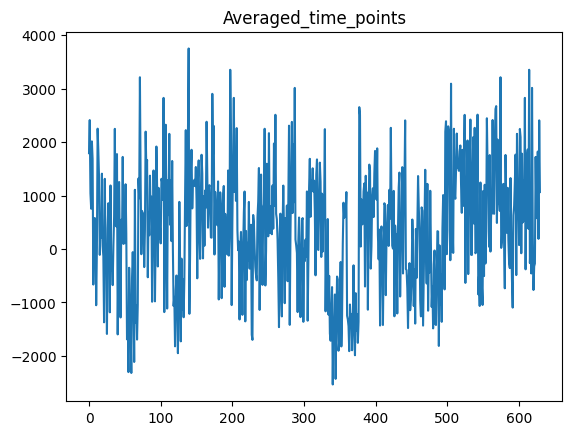

In [ ]:
#Compute distance matrix
distance_matrix = []

channel_columns = [col for col in dfs.columns if col.startswith('channel_')]
signal = dfs[channel_columns].to_numpy()

sample_features = []
for f in range(1, cell_array.shape[0]+1):  # Loop through each sample
# Number of time points
    sample_signal = signal[dfs['sample'] == f]   #source of 7500 rows in output

# Number of channels
    nc = signal.shape[1]

# Store distance matrices
    friendship_matrix = np.zeros((nc,nc))  # Initialize friendship matrix with zeros
    n_features = nc * (nc - 1) // 2

    sample_friend = np.zeros((sample_signal.shape[0], n_features))
    #sample_friend = pd.Series()  # Initialize list to store friendship matrices for each time point
    for i in range(sample_signal.shape[0]):  #Create friendship matrix for each time point of a sample

    # S1: Create channel vector
        cv = sample_signal[i, :nc]   #This takes the first row of the signal matrix for each time point, which contains the values for all channels at that specific time point.

    # S2: Compute L1 distance matrix
        cv = np.asarray(cv).ravel()
        D = np.abs(cv[:, None] - cv[None, :])
                                                    #print(D.shape)  shape is (nc, nc) for each time point
    #calculate average distance for single time point
        average_distance = np.mean(D)
        lower_triangle = np.tril_indices(nc, k=-1)
    # Keep only the upper triangle, including the diagonal.
        D[lower_triangle] = np.nan
    # Compute the mean using valid distances only.
        average_distance = np.nanmean(D)

        threshold = average_distance  # Define a threshold for friendship
        friendship_matrix[D<=threshold] += 1 
        friendship_matrix[D>threshold] -= 1
   
        min_row, min_col = np.unravel_index(np.nanargmin(D), D.shape)
        max_row, max_col = np.unravel_index(np.nanargmax(D), D.shape)
        friendship_matrix[min_row, min_col] += 1  
        friendship_matrix[max_row, max_col] -= 1

        #sample_friend = pd.concat([sample_friend, pd.Series(friendship_matrix[np.triu_indices(nc, k=1)])], ignore_index=True)
        sample_friend[i, :] = friendship_matrix[np.triu_indices(nc, k=1)]  # Store the upper triangle of the friendship matrix for the current time point
        # print(f"sample_friend shape: {sample_friend[i, :].shape}")
    sample_friend = np.mean(sample_friend, axis=0)  # Average across time points
    #print(f"sample_friend shape: {sample_friend.shape}")

    sample_features.append(sample_friend)  # Store the averaged friendship values for the sample]) 
print(np.array(sample_features).shape)

# Each feature (one of 630) represents a unique pair of channels, and each row corresponds to a sample. The resulting shape is (number of samples, number of unique channel pairs).
    

In [8]:
sample_friend.shape


(7500, 630)

In [58]:
features_df = pd.DataFrame(sample_features)
features_df.columns = [f'feature_{i+1}' for i in range(features_df.shape[1])]
features_df.index = [f'sample_{i+1}' for i in range(features_df.shape[0])]

In [59]:
# Add y labels for classification
features_df['class'] = [label] * features_df.shape[0]  # Placeholder for labels, replace with actual labels if available   

In [60]:
# Save the features DataFrame to a CSV file
output_csv_path = f"C:\\Users\\Sikhulile\\Downloads\\Dataframe classified Epilepsy data\\{index}_{distinct_label if label == 1 else 'healthy'}.csv"
features_df.to_csv(output_csv_path, index=False)